In [152]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import scipy

from enum import Enum

class VideoCategories(Enum):
    ARTS = 'arts'
    BIOLOGY = 'biology'
    BUSINESS = 'business'
    CHEMISTRY = 'chemistry'
    COMPUTER_SCIENCE = 'computer_science'
    LITERATURE = 'literature'
    MATHEMATICS = 'mathematics'
    MUSIC = 'music'
    PHYSICS = 'physics'
    PSYCHOLOGY = 'psychology'

def convert_to_numpy(vector: str):
    return np.array([float(v) for v in vector.split(' ')])

def convert_to_string(vector: np.array):
    return ' '.join(str(v) for v in vector)

In [153]:
videos_df = pd.read_csv('videos.csv')
videos_multiple_df = pd.read_csv('videos_multiple.csv')
profiling_df = pd.read_csv('profiling.csv')
profiling_2_df = pd.read_csv('profiling_2.csv')
profiling_3_df = pd.read_csv('profiling_3.csv')
profiling_4_df = pd.read_csv('profiling_4.csv')
profiling_5_df = pd.read_csv('profiling_5.csv')
profiling_multiple_df = pd.read_csv('profiling_multiple.csv')
recommending_df = pd.read_csv('recommending.csv')
recommending_2_df = pd.read_csv('recommending_2.csv')
recommending_3_df = pd.read_csv('recommending_3.csv')
recommending_4_df = pd.read_csv('recommending_4.csv')
recommending_5_df = pd.read_csv('recommending_5.csv')
recommending_multiple_df = pd.read_csv('recommending_multiple.csv')

---
# Profiling preparation
---

In [154]:
##################################################################
# Experiment 1
bot_vectors = profiling_df['bot_vector'].to_list()
vectors = []
for v in bot_vectors:
    vectors.append(v.replace('0.1', '0.0'))
profiling_df['bot_vector'] = vectors
##################################################################

##################################################################
# Experiment 2
bot_vectors = profiling_2_df['bot_vector'].to_list()
vectors = []
for v in bot_vectors:
    vectors.append(v.replace('0.1', '0.0'))
profiling_2_df['bot_vector'] = vectors
##################################################################

##################################################################
# Experiment 3
bot_vectors = profiling_3_df['bot_vector'].to_list()
vectors = []
for v in bot_vectors:
    vectors.append(v.replace('0.1', '0.0'))
profiling_3_df['bot_vector'] = vectors
##################################################################

##################################################################
# Experiment 4
bot_vectors = profiling_4_df['bot_vector'].to_list()
vectors = []
for v in bot_vectors:
    vectors.append(v.replace('0.1', '0.0'))
profiling_4_df['bot_vector'] = vectors
##################################################################

##################################################################
# Experiment 5
bot_vectors = profiling_5_df['bot_vector'].to_list()
vectors = []
for v in bot_vectors:
    vectors.append(v.replace('0.1', '0.0'))
profiling_5_df['bot_vector'] = vectors
##################################################################

##################################################################
# Experiment multiple
bot_vectors = profiling_multiple_df['bot_vector'].to_list()
vectors = []
for v in bot_vectors:
    vectors.append(v.replace('0.1', '0.0'))
profiling_multiple_df['bot_vector'] = vectors
##################################################################

profiling_df.head(10)

,id,username,bot_vector,user_vector
0,1,bot1,0.0 0.0 0.0 0.0 0.3 0.0 0.7 0.0 0.5 0.0,0.0030325 0.0000119 0.0000134 0.0000134 0.5138...
1,2,bot2,0.0 0.0 0.3 0.0 0.0 0.3 0.0 0.0 0.0 0.0,0.3232141 0.0000705 0.5243481 0.3471546 0.0000...
2,3,bot3,0.0 0.3 0.0 0.3 0.0 0.0 0.3 0.0 0.5 0.0,0.0095892 0.4658359 0.0000133 0.4755106 0.0000...
3,4,bot4,0.0 0.0 0.3 0.0 0.0 0.5 0.0 0.0 0.0 0.0,0.3630260 0.0001041 0.5640381 0.0001228 0.0000...
4,5,bot5,0.0 0.0 0.0 0.0 0.9 0.0 0.5 0.0 0.9 0.0,0.0000307 0.0000044 0.0000044 0.0000044 0.6435...
5,6,bot6,0.0 0.0 0.0 0.0 0.3 0.0 0.0 0.0 0.5 0.0,0.3016300 0.0000508 0.2858927 0.0000512 0.5619...
6,7,bot7,0.0 0.0 0.0 0.0 0.7 0.0 0.7 0.0 0.5 0.0,-0.0000116 0.0000052 0.0000105 0.0000052 0.607...
7,8,bot8,0.0 0.0 0.7 0.0 0.0 0.3 0.0 0.0 0.0 0.0,0.3092875 0.0000396 0.6306834 0.0000450 0.0000...
8,9,bot9,0.3 0.0 0.0 0.0 0.0 0.7 0.0 0.7 0.0 0.7,0.3594540 0.0000048 0.0000048 0.0000048 0.0000...
9,10,bot10,0.0 0.0 0.0 0.0 0.9 0.0 0.3 0.0 0.9 0.0,0.0008610 0.0000043 0.0000043 0.0000043 0.6676...


In [155]:
def convert_to_numpy(vector: str):
    return np.array([float(v) for v in vector.split(' ')])

def cosine_similarity(bot_vector, user_vector):
    dot_product = np.dot(bot_vector, user_vector)
    norm_bot = np.linalg.norm(bot_vector)
    norm_user = np.linalg.norm(user_vector)
    return dot_product / (norm_bot * norm_user)

##################################################################
# Experiment 1
similarities = []
for b, u in zip(profiling_df['bot_vector'], profiling_df['user_vector']):
    bot_vector = convert_to_numpy(b)
    user_vector = convert_to_numpy(u)

    # Calculating similarity
    similarities.append(cosine_similarity(bot_vector, user_vector))
print(f'len_similarities_exp_1: {len(similarities)}')
profiling_df['similarity'] = similarities
##################################################################

##################################################################
# Experiment 2
similarities = []
for b, u in zip(profiling_2_df['bot_vector'], profiling_2_df['user_vector']):
    bot_vector = convert_to_numpy(b)
    user_vector = convert_to_numpy(u)

    # Calculating similarity
    similarities.append(cosine_similarity(bot_vector, user_vector))
print(f'len_similarities_exp_2: {len(similarities)}')
profiling_2_df['similarity'] = similarities
##################################################################

##################################################################
# Experiment 3
similarities = []
for b, u in zip(profiling_3_df['bot_vector'], profiling_3_df['user_vector']):
    bot_vector = convert_to_numpy(b)
    user_vector = convert_to_numpy(u)

    # Calculating similarity
    similarities.append(cosine_similarity(bot_vector, user_vector))
print(f'len_similarities_exp_3: {len(similarities)}')
profiling_3_df['similarity'] = similarities
##################################################################

#################################################################
# Experiment 4
similarities = []
for b, u in zip(profiling_4_df['bot_vector'], profiling_4_df['user_vector']):
    bot_vector = convert_to_numpy(b)
    user_vector = convert_to_numpy(u)

    # Calculating similarity
    similarities.append(cosine_similarity(bot_vector, user_vector))
print(f'len_similarities_exp_4: {len(similarities)}')
profiling_4_df['similarity'] = similarities
#################################################################

#################################################################
# Experiment 5
similarities = []
for b, u in zip(profiling_5_df['bot_vector'], profiling_5_df['user_vector']):
    bot_vector = convert_to_numpy(b)
    user_vector = convert_to_numpy(u)

    # Calculating similarity
    similarities.append(cosine_similarity(bot_vector, user_vector))
print(f'len_similarities_exp_5: {len(similarities)}')
profiling_5_df['similarity'] = similarities
#################################################################

#################################################################
# Experiment multiple
similarities = []
for b, u in zip(profiling_multiple_df['bot_vector'], profiling_5_df['user_vector']):
    bot_vector = convert_to_numpy(b)
    user_vector = convert_to_numpy(u)

    # Calculating similarity
    similarities.append(cosine_similarity(bot_vector, user_vector))
print(f'len_similarities_exp_multiple: {len(similarities)}')
profiling_multiple_df['similarity'] = similarities
#################################################################

len_similarities_exp_1: 94
len_similarities_exp_2: 94
len_similarities_exp_3: 94
len_similarities_exp_4: 94
len_similarities_exp_5: 94
len_similarities_exp_multiple: 1


---
# Recommending preparation
---

In [156]:
categories = [category.value for category in VideoCategories]

##################################################################
# Experiment 1
bot_vectors = recommending_df['vector'].to_list()
vectors = []
for v in bot_vectors:
    vectors.append(v.replace('0.1', '0.0'))
recommending_df['vector'] = vectors

profiles = []
for v in recommending_df['vector'].to_list():
    profile = []
    vector = v.split(' ')
    for i in range(len(vector)):
        if vector[i] != '0.0':
            profile.append(categories[i])

    profiles.append(' '.join(profile))
recommending_df['profile'] = profiles
##################################################################

##################################################################
# Experiment 2
bot_vectors = recommending_2_df['vector'].to_list()
vectors = []
for v in bot_vectors:
    vectors.append(v.replace('0.1', '0.0'))
recommending_2_df['vector'] = vectors

profiles = []
for v in recommending_2_df['vector'].to_list():
    profile = []
    vector = v.split(' ')
    for i in range(len(vector)):
        if vector[i] != '0.0':
            profile.append(categories[i])

    profiles.append(' '.join(profile))
recommending_2_df['profile'] = profiles
##################################################################

##################################################################
#Experiment 3
bot_vectors = recommending_3_df['vector'].to_list()
vectors = []
for v in bot_vectors:
    vectors.append(v.replace('0.1', '0.0'))
recommending_3_df['vector'] = vectors

profiles = []
for v in recommending_3_df['vector'].to_list():
    profile = []
    vector = v.split(' ')
    for i in range(len(vector)):
        if vector[i] != '0.0':
            profile.append(categories[i])

    profiles.append(' '.join(profile))
recommending_3_df['profile'] = profiles
##################################################################

#################################################################
#Experiment 4
bot_vectors = recommending_4_df['vector'].to_list()
vectors = []
for v in bot_vectors:
    vectors.append(v.replace('0.1', '0.0'))
recommending_4_df['vector'] = vectors

profiles = []
for v in recommending_4_df['vector'].to_list():
    profile = []
    vector = v.split(' ')
    for i in range(len(vector)):
        if vector[i] != '0.0':
            profile.append(categories[i])

    profiles.append(' '.join(profile))
recommending_4_df['profile'] = profiles
#################################################################

#################################################################
#Experiment 5
bot_vectors = recommending_5_df['vector'].to_list()
vectors = []
for v in bot_vectors:
    vectors.append(v.replace('0.1', '0.0'))
recommending_5_df['vector'] = vectors

profiles = []
for v in recommending_5_df['vector'].to_list():
    profile = []
    vector = v.split(' ')
    for i in range(len(vector)):
        if vector[i] != '0.0':
            profile.append(categories[i])

    profiles.append(' '.join(profile))
recommending_5_df['profile'] = profiles
#################################################################

#################################################################
#Experiment multiple
bot_vectors = recommending_multiple_df['vector'].to_list()
vectors = []
for v in bot_vectors:
    vectors.append(v.replace('0.1', '0.0'))
recommending_multiple_df['vector'] = vectors

profiles = []
for v in recommending_multiple_df['vector'].to_list():
    profile = []
    vector = v.split(' ')
    for i in range(len(vector)):
        if vector[i] != '0.0':
            profile.append(categories[i])

    profiles.append(' '.join(profile))
recommending_multiple_df['profile'] = profiles
#################################################################

recommending_df.head(10)

,user,vector,video_id,categories,action_type,action_duration,video_duration,profile
0,bot2,0.0 0.0 0.3 0.0 0.0 0.3 0.0 0.0 0.0 0.0,1,arts,NaN,10000,50000,business literature
1,bot4,0.0 0.0 0.3 0.0 0.0 0.5 0.0 0.0 0.0 0.0,1,arts,NaN,5500,50000,business literature
2,bot6,0.0 0.0 0.0 0.0 0.3 0.0 0.0 0.0 0.5 0.0,1,arts,NaN,3000,50000,computer_science physics
3,bot8,0.0 0.0 0.7 0.0 0.0 0.3 0.0 0.0 0.0 0.0,1,arts,NaN,2000,50000,business literature
4,bot9,0.3 0.0 0.0 0.0 0.0 0.7 0.0 0.7 0.0 0.7,1,arts,NaN,13500,50000,arts literature music psychology
5,bot11,0.7 0.0 0.0 0.0 0.0 0.7 0.0 0.5 0.0 0.3,1,arts,like,32000,50000,arts literature music psychology
6,bot12,0.5 0.0 0.0 0.0 0.0 0.7 0.0 0.3 0.0 0.5,1,arts,NaN,25000,50000,arts literature music psychology
7,bot13,0.0 0.0 0.9 0.0 0.0 0.0 0.0 0.0 0.0 0.7,1,arts,NaN,2000,50000,business psychology
8,bot15,0.0 0.0 0.0 0.0 0.0 0.0 0.7 0.0 0.3 0.0,1,arts,NaN,9000,50000,mathematics physics
9,bot17,0.0 0.0 0.0 0.0 0.0 0.0 0.5 0.0 0.7 0.0,1,arts,NaN,2000,50000,mathematics physics


---
## Experiment 1
---

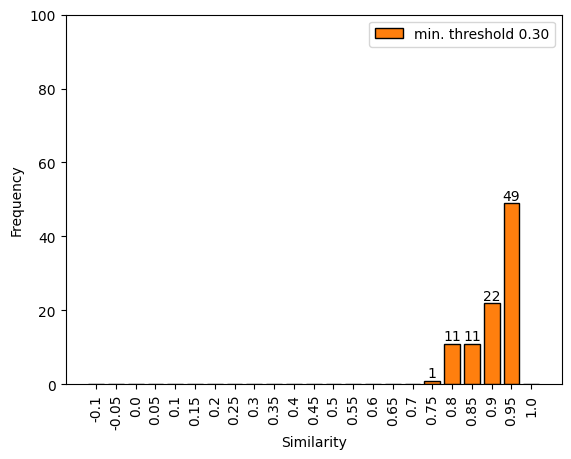

In [157]:
classes = []
index = -0.1
while index <= 1:
    classes.append(index)
    index += 0.05
    index = round(index, 2)
display_classes = [str(c) for c in classes]

values = [0 for _ in range(len(classes))]
for s in profiling_df['similarity'].to_list():
    flag = False
    for i in range(0, len(classes) - 1):
        if flag:
            continue
        lower_bound = classes[i]
        upper_bound = classes[i+1]
        if s >= lower_bound and s < upper_bound:
            flag = True
            values[i]+=1
    if not flag:
        values[len(classes) - 1]+=1

plt.bar(display_classes, values, edgecolor='black', color='tab:orange', label='min. threshold 0.30')

# plt.title('Experiment 1: bot and user vector similarities distribution')
plt.legend()
plt.xlabel('Similarity')
plt.ylabel('Frequency')
plt.ylim(0,100)
plt.xticks(display_classes, rotation=90)

# Display the number of elements on top of each bar
for i, value in enumerate(values):
    if value != 0:
        plt.text(i, value, str(value), ha='center', va='bottom')

plt.show()

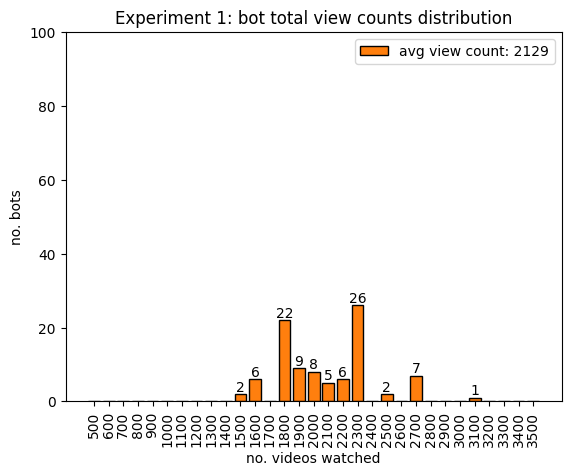

In [158]:
total_view_counts = recommending_df.groupby('user').size().reset_index(name='view_count')

avg_total_views = sum(total_view_counts['view_count'].to_list()) // len(total_view_counts['view_count'].to_list())

classes = []
index = 500
while index <= 3500:
    classes.append(index)
    index += 100
display_classes = [str(c) for c in classes]

values = [0 for _ in range(len(classes))]
for v in total_view_counts['view_count'].to_list():
    flag = False
    for i in range(0, len(classes) - 1):
        if flag:
            continue
        lower_bound = classes[i]
        upper_bound = classes[i+1]
        if v >= lower_bound and v < upper_bound:
            flag = True
            values[i]+=1
    if not flag:
        values[len(classes) - 1]+=1

plt.bar(display_classes, values, edgecolor='black', color='tab:orange', label=f'avg view count: {avg_total_views}')

plt.title('Experiment 1: bot total view counts distribution')
plt.legend()
plt.xlabel('no. videos watched')
plt.ylabel('no. bots')
plt.ylim(0,100)
plt.xticks(display_classes, rotation=90)

# Display the number of elements on top of each bar
for i, value in enumerate(values):
    if value != 0:
        plt.text(i, value, str(value), ha='center', va='bottom')

plt.show()

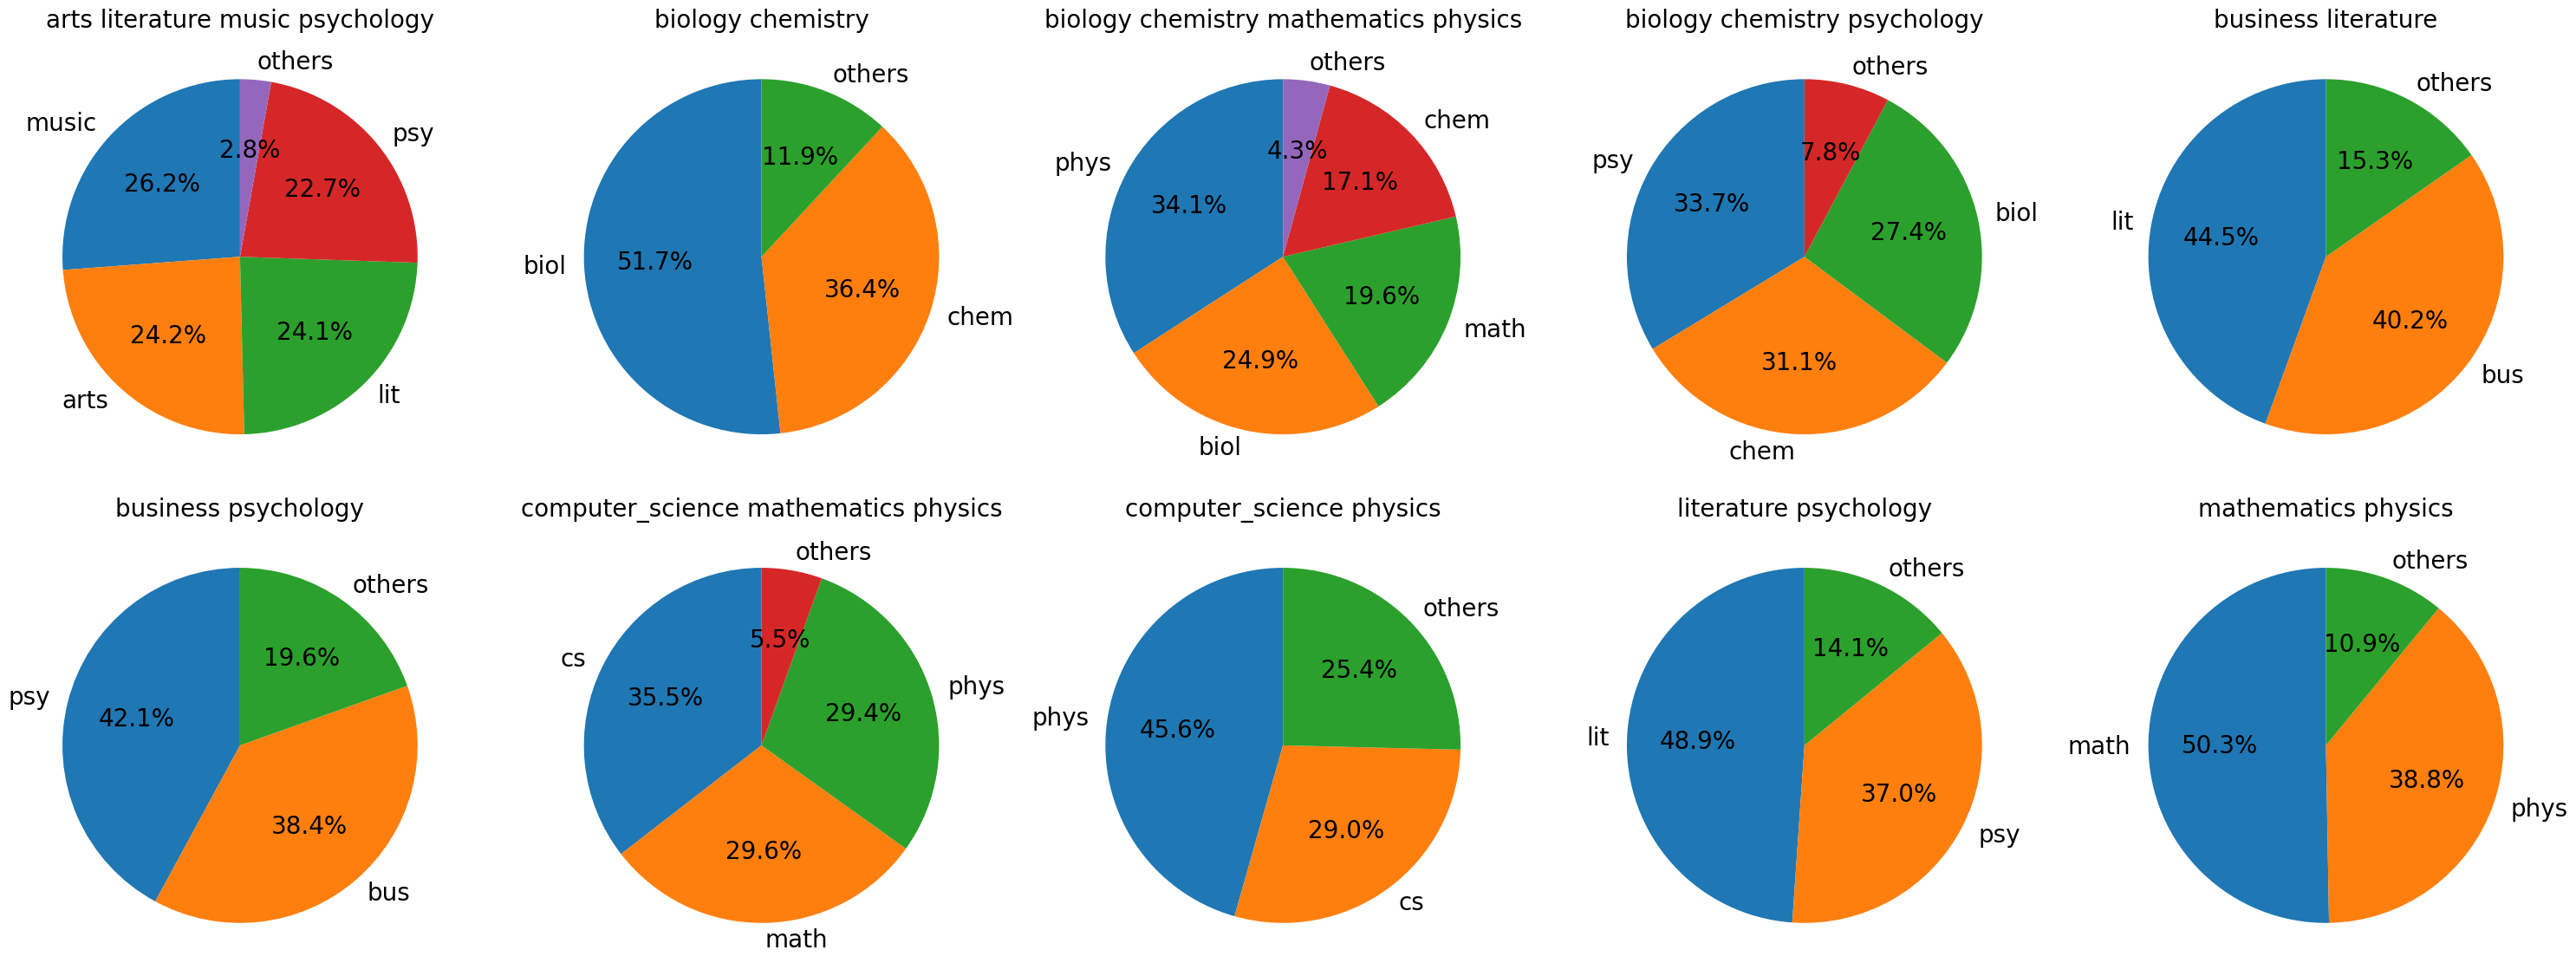

In [159]:
def format_duration(milliseconds):
    seconds, ms = divmod(milliseconds, 1000)
    minutes, seconds = divmod(seconds, 60)
    hours, minutes = divmod(minutes, 60)
    
    formatted_duration = f"{hours:02}:{minutes:02}:{seconds:02}.{ms:03}"
    return formatted_duration

watch_times = recommending_df.groupby(['profile', 'categories'])['action_duration'].sum().reset_index(name='total_watch_time')
total_watch_time_df = watch_times.groupby('profile')['total_watch_time'].sum().reset_index(name='total_watch_time')

# print(watch_times.head(10))
# print(total_watch_time_df.head(10))

profiles = total_watch_time_df['profile'].unique()
totals = total_watch_time_df['total_watch_time'].to_list()

disciplines = ['arts', 'biol', 'bus', 'chem', 'cs', 'lit', 'math', 'music', 'phys', 'psy']

data = {p: [] for p in profiles}
for p, t in zip(profiles, totals):
    watch_percentages = []
    times = watch_times[watch_times['profile'] == p]
    for time in times['total_watch_time'].to_list():
        percentage = time * 100 / t
        # percentage = round(percentage, 2)
        watch_percentages.append(percentage)
    data[p] = watch_percentages

# for key, value in data.items():
#     print(key)
#     print(value)
#     print('---')

# Number of profiles and disciplines
n_profiles = len(profiles)
n_disciplines = len(disciplines)

# Set up the figure with a grid of subplots
cols = 5
rows = (n_profiles + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(30, 12))

# Ensure axes is always iterable
axes = axes.flatten()

# Plot data for each profile
for i, profile in enumerate(profiles):
    values = data[profile].copy()
    labels = disciplines.copy()

    # print(profile)
    # print('before sorting')
    # print(labels)
    # print(values)

    # Sorting list
    for index in range(len(values) - 1):
        for jndex in range(index + 1, len(values)):
            if values[jndex] > values[index]:
                # Swapping values
                copy = values[index]
                values[index] = values[jndex]
                values[jndex] = copy

                # Swapping disciplines
                copy = labels[index]
                labels[index] = labels[jndex]
                labels[jndex] = copy

    # print('after sorting')
    # print(labels)
    # print(values)

    # print()


    total = 0
    data_points = []
    display = []
    for v, l in zip(values, labels):
        if v >= 10:
            data_points.append(v)
            display.append(l)
        else:
            total += v
    
    data_points.append(total)
    display.append('others')

    # explode = [0.1] * len(data_points)
    wedges, texts, autotexts = axes[i].pie(data_points, labels=display, autopct='%1.1f%%', startangle=90, textprops={'fontsize': 20})
    axes[i].set_title(profile, fontsize=20)

    # # Create legend with labels and percentages
    # legend_labels = [f'{label} ({value:.1f}%)' for label, value in zip(display, data_points)]
    # axes[i].legend(wedges, legend_labels, loc="right", bbox_to_anchor=(1.5, 0.5), fontsize=18)

# Remove empty subplots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

# Add a big title to the whole plot
# fig.suptitle('Experiment 1: watch percentage by category per profile', fontsize=22)

# Display plot
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

---
## Experiment 2
---

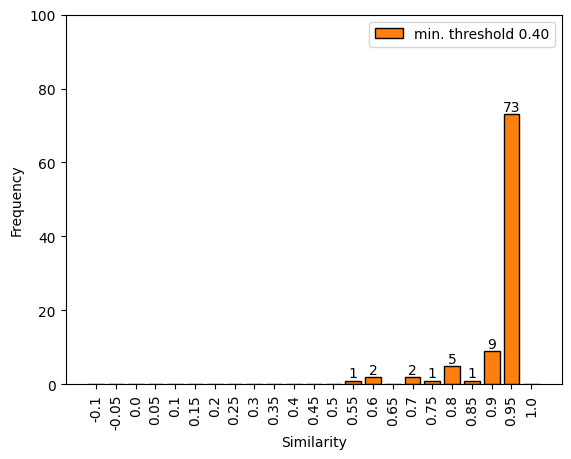

In [160]:
classes = []
index = -0.1
while index <= 1:
    classes.append(index)
    index += 0.05
    index = round(index, 2)
display_classes = [str(c) for c in classes]

values = [0 for _ in range(len(classes))]
for s in profiling_2_df['similarity'].to_list():
    flag = False
    for i in range(0, len(classes) - 1):
        if flag:
            continue
        lower_bound = classes[i]
        upper_bound = classes[i+1]
        if s >= lower_bound and s < upper_bound:
            flag = True
            values[i]+=1
    if not flag:
        values[len(classes) - 1]+=1

plt.bar(display_classes, values, edgecolor='black', color='tab:orange', label='min. threshold 0.40')

# plt.title('Experiment 2: bot and user vector similarities distribution')
plt.legend()
plt.xlabel('Similarity')
plt.ylabel('Frequency')
plt.ylim(0,100)
plt.xticks(display_classes, rotation=90)

# Display the number of elements on top of each bar
for i, value in enumerate(values):
    if value != 0:
        plt.text(i, value, str(value), ha='center', va='bottom')

plt.show()

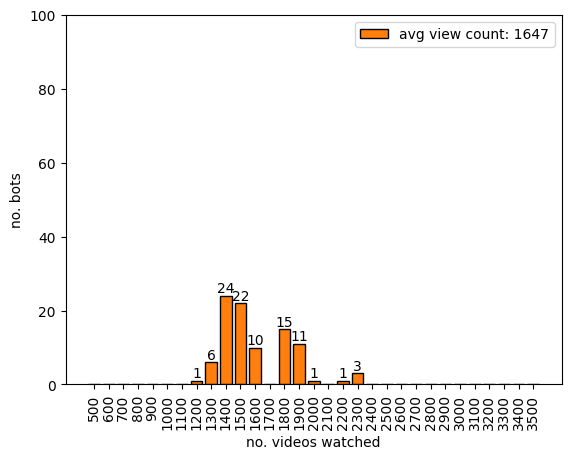

In [161]:
total_view_counts = recommending_2_df.groupby('user').size().reset_index(name='view_count')

avg_total_views = sum(total_view_counts['view_count'].to_list()) // len(total_view_counts['view_count'].to_list())

classes = []
index = 500
while index <= 3500:
    classes.append(index)
    index += 100
display_classes = [str(c) for c in classes]

values = [0 for _ in range(len(classes))]
for v in total_view_counts['view_count'].to_list():
    flag = False
    for i in range(0, len(classes) - 1):
        if flag:
            continue
        lower_bound = classes[i]
        upper_bound = classes[i+1]
        if v >= lower_bound and v < upper_bound:
            flag = True
            values[i]+=1
    if not flag:
        values[len(classes) - 1]+=1

plt.bar(display_classes, values, edgecolor='black', color='tab:orange', label=f'avg view count: {avg_total_views}')

# plt.title('Experiment 2: bot total view counts distribution')
plt.legend()
plt.xlabel('no. videos watched')
plt.ylabel('no. bots')
plt.ylim(0,100)
plt.xticks(display_classes, rotation=90)

# Display the number of elements on top of each bar
for i, value in enumerate(values):
    if value != 0:
        plt.text(i, value, str(value), ha='center', va='bottom')

plt.show()

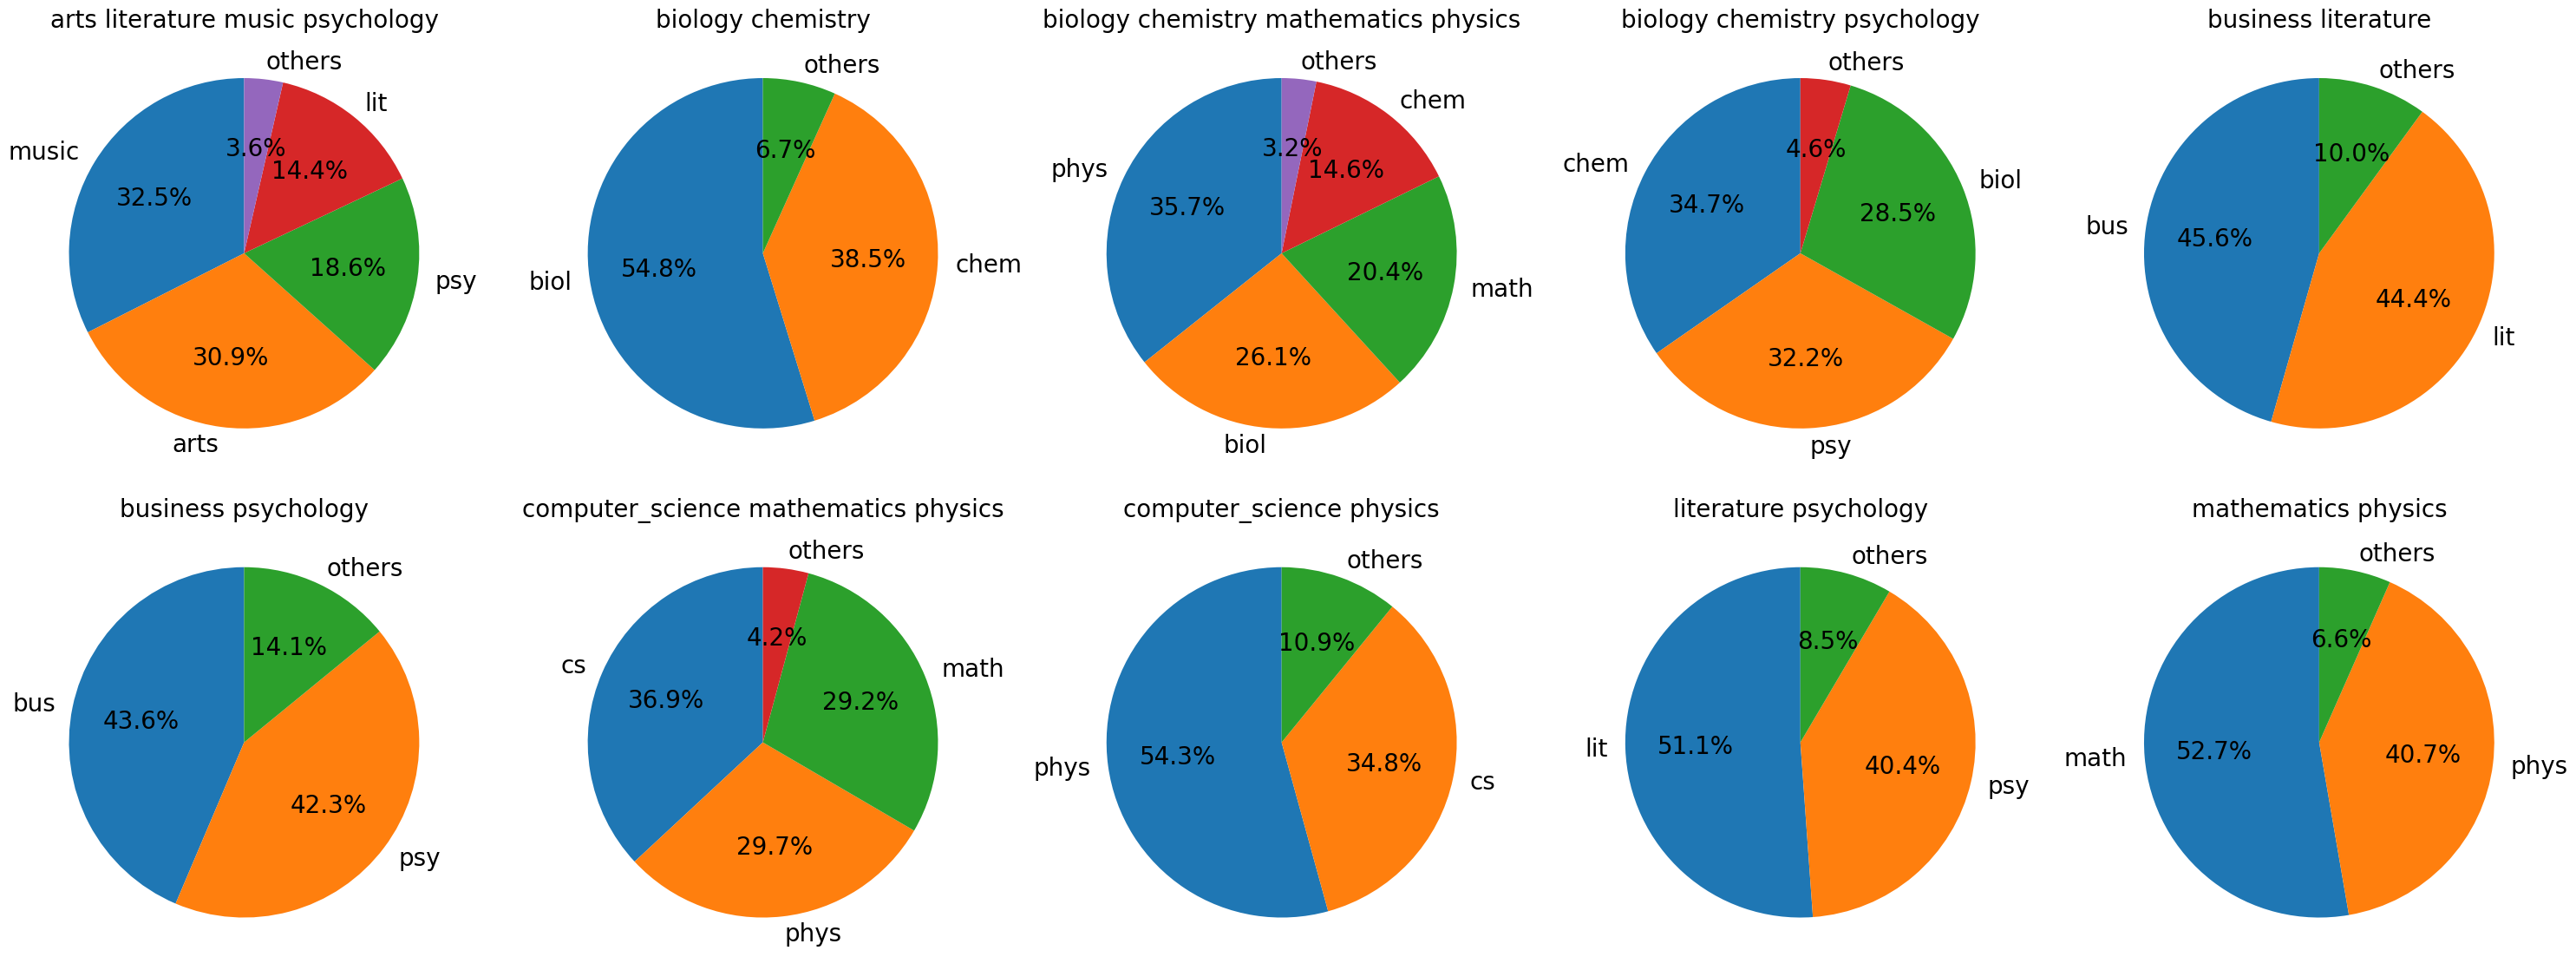

In [162]:
def format_duration(milliseconds):
    seconds, ms = divmod(milliseconds, 1000)
    minutes, seconds = divmod(seconds, 60)
    hours, minutes = divmod(minutes, 60)
    
    formatted_duration = f"{hours:02}:{minutes:02}:{seconds:02}.{ms:03}"
    return formatted_duration

watch_times = recommending_2_df.groupby(['profile', 'categories'])['action_duration'].sum().reset_index(name='total_watch_time')
total_watch_time_df = watch_times.groupby('profile')['total_watch_time'].sum().reset_index(name='total_watch_time')

# print(watch_times.head(10))
# print(total_watch_time_df.head(10))

profiles = total_watch_time_df['profile'].unique()
totals = total_watch_time_df['total_watch_time'].to_list()

disciplines = ['arts', 'biol', 'bus', 'chem', 'cs', 'lit', 'math', 'music', 'phys', 'psy']

data = {p: [] for p in profiles}
for p, t in zip(profiles, totals):
    watch_percentages = []
    times = watch_times[watch_times['profile'] == p]
    for time in times['total_watch_time'].to_list():
        percentage = time * 100 / t
        # percentage = round(percentage, 2)
        watch_percentages.append(percentage)
    data[p] = watch_percentages

# for key, value in data.items():
#     print(key)
#     print(value)
#     print('---')

# Number of profiles and disciplines
n_profiles = len(profiles)
n_disciplines = len(disciplines)

# Set up the figure with a grid of subplots
cols = 5
rows = (n_profiles + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(30, 12))

# Ensure axes is always iterable
axes = axes.flatten()

# Plot data for each profile
for i, profile in enumerate(profiles):
    values = data[profile].copy()
    labels = disciplines.copy()

    # print(profile)
    # print('before sorting')
    # print(labels)
    # print(values)

    # Sorting list
    for index in range(len(values) - 1):
        for jndex in range(index + 1, len(values)):
            if values[jndex] > values[index]:
                # Swapping values
                copy = values[index]
                values[index] = values[jndex]
                values[jndex] = copy

                # Swapping disciplines
                copy = labels[index]
                labels[index] = labels[jndex]
                labels[jndex] = copy

    # print('after sorting')
    # print(labels)
    # print(values)

    # print()


    total = 0
    data_points = []
    display = []
    for v, l in zip(values, labels):
        if v >= 10:
            data_points.append(v)
            display.append(l)
        else:
            total += v
    
    data_points.append(total)
    display.append('others')

    # explode = [0.1] * len(data_points)
    wedges, texts, autotexts = axes[i].pie(data_points, labels=display, autopct='%1.1f%%', startangle=90, textprops={'fontsize': 20})
    axes[i].set_title(profile, fontsize=20)

    # # Create legend with labels and percentages
    # legend_labels = [f'{label} ({value:.1f}%)' for label, value in zip(display, data_points)]
    # axes[i].legend(wedges, legend_labels, loc="right", bbox_to_anchor=(1.5, 0.5), fontsize=18)

# Remove empty subplots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

# Add a big title to the whole plot
# fig.suptitle('Experiment 2: watch percentage by category per profile', fontsize=22)

# Display plot
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

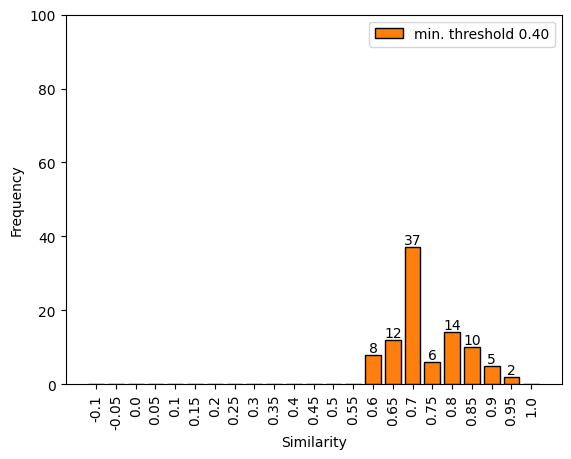

In [163]:
spearman_correlations = []
for index, row in profiling_2_df.iterrows():
    bot_vector = convert_to_numpy(row.__getitem__('bot_vector'))
    user_vector = convert_to_numpy(row.__getitem__('user_vector'))
    
    bot_magnitude = np.linalg.norm(bot_vector)
    user_magnitude = np.linalg.norm(user_vector)

    bot_vector_normalized = bot_vector / bot_magnitude
    user_vector_normalized = user_vector / user_magnitude

    spearman_corr, _ = scipy.stats.spearmanr(bot_vector_normalized, user_vector_normalized)
    spearman_correlations.append(spearman_corr)

classes = []
index = -0.1
while index <= 1:
    classes.append(index)
    index += 0.05
    index = round(index, 2)
display_classes = [str(c) for c in classes]

values = [0 for _ in range(len(classes))]
for s in spearman_correlations:
    flag = False
    for i in range(0, len(classes) - 1):
        if flag:
            continue
        lower_bound = classes[i]
        upper_bound = classes[i+1]
        if s >= lower_bound and s < upper_bound:
            flag = True
            values[i]+=1
    if not flag:
        values[len(classes) - 1]+=1

plt.bar(display_classes, values, edgecolor='black', color='tab:orange', label='min. threshold 0.40')

# plt.title('Distribution of Spearman Rank Correlation Coefficients')
plt.legend()
plt.xlabel('Similarity')
plt.ylabel('Frequency')
plt.ylim(0,100)
plt.xticks(display_classes, rotation=90)

# Display the number of elements on top of each bar
for i, value in enumerate(values):
    if value != 0:
        plt.text(i, value, str(value), ha='center', va='bottom')

plt.show()

In [164]:
# recommending_2_df.head(10)
# bots = profiling_2_df.groupby(['username', 'bot_vector'])
# bots = bots[['username', 'bot_vector']]
# bots.head(10)

# for row, fuck_off in bots:
#     user = row[0]
#     vector = row[1]
#     vector_list = vector.split(' ')
#     disciplines = [category.value for category in VideoCategories]
#     interest_levels = {category.value:0 for category in VideoCategories}
#     for index in range(len(vector_list)):
#         if vector_list[index] == '0.0':
#             interest_levels[disciplines[index]] = 1
#             continue
#         if vector_list[index] == '0.3':
#             interest_levels[disciplines[index]] = 2
#             continue
#         if vector_list[index] == '0.5':
#             interest_levels[disciplines[index]] = 3
#             continue
#         if vector_list[index] == '0.7':
#             interest_levels[disciplines[index]] = 4
#             continue
#         if vector_list[index] == '0.9':
#             interest_levels[disciplines[index]] = 5
#             continue

#     watch_times_category = {category.value: 0 for category in VideoCategories}

#     filtered_df = recommending_2_df[recommending_2_df['user'] == user]
#     filtered_df = filtered_df[['user', 'categories', 'action_duration', 'video_duration']]
#     total_watch_time_bot = sum(filtered_df['video_duration'])

#     for index, row in filtered_df.iterrows():
#         category = row.__getitem__('categories')
#         action_duration = row.__getitem__('action_duration')
#         watch_times_category[category] += action_duration

#     watch_times_interest_level = {i: 0 for i in range(1, 6)}
#     for key, value in interest_levels.items():
#         watch_times_interest_level[value] += watch_times_category[key]
    
#     print(total_watch_time_bot)
#     print(watch_times_category)
#     print(interest_levels)
#     print(watch_times_interest_level)

    

---
## Experiment 3
---

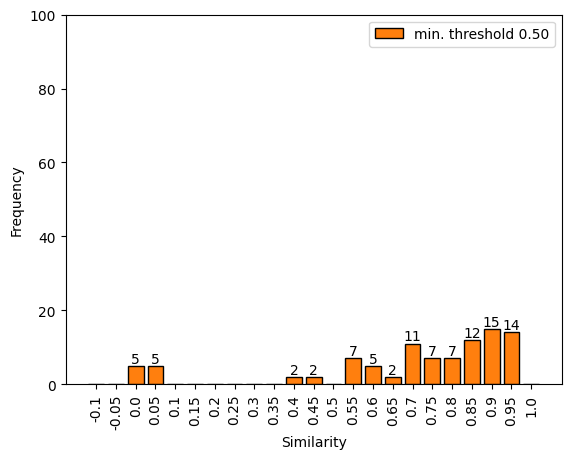

In [165]:
classes = []
index = -0.1
while index <= 1:
    classes.append(index)
    index += 0.05
    index = round(index, 2)
display_classes = [str(c) for c in classes]

values = [0 for _ in range(len(classes))]
for s in profiling_3_df['similarity'].to_list():
    flag = False
    for i in range(0, len(classes) - 1):
        if flag:
            continue
        lower_bound = classes[i]
        upper_bound = classes[i+1]
        if s >= lower_bound and s < upper_bound:
            flag = True
            values[i]+=1
    if not flag:
        values[len(classes) - 1]+=1

plt.bar(display_classes, values, edgecolor='black', color='tab:orange', label='min. threshold 0.50')

# plt.title('Experiment 3: bot and user vector similarities distribution')
plt.legend()
plt.xlabel('Similarity')
plt.ylabel('Frequency')
plt.ylim(0,100)
plt.xticks(display_classes, rotation=90)

# Display the number of elements on top of each bar
for i, value in enumerate(values):
    if value != 0:
        plt.text(i, value, str(value), ha='center', va='bottom')

plt.show()

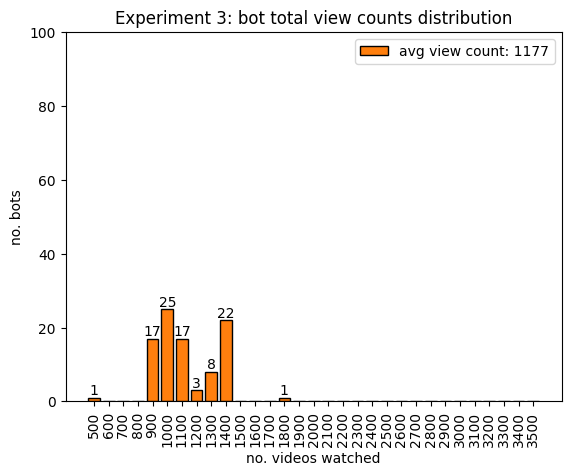

In [166]:
total_view_counts = recommending_3_df.groupby('user').size().reset_index(name='view_count')

avg_total_views = sum(total_view_counts['view_count'].to_list()) // len(total_view_counts['view_count'].to_list())

classes = []
index = 500
while index <= 3500:
    classes.append(index)
    index += 100
display_classes = [str(c) for c in classes]

values = [0 for _ in range(len(classes))]
for v in total_view_counts['view_count'].to_list():
    flag = False
    for i in range(0, len(classes) - 1):
        if flag:
            continue
        lower_bound = classes[i]
        upper_bound = classes[i+1]
        if v >= lower_bound and v < upper_bound:
            flag = True
            values[i]+=1
    if not flag:
        values[len(classes) - 1]+=1

plt.bar(display_classes, values, edgecolor='black', color='tab:orange', label=f'avg view count: {avg_total_views}')

plt.title('Experiment 3: bot total view counts distribution')
plt.legend()
plt.xlabel('no. videos watched')
plt.ylabel('no. bots')
plt.ylim(0,100)
plt.xticks(display_classes, rotation=90)

# Display the number of elements on top of each bar
for i, value in enumerate(values):
    if value != 0:
        plt.text(i, value, str(value), ha='center', va='bottom')

plt.show()

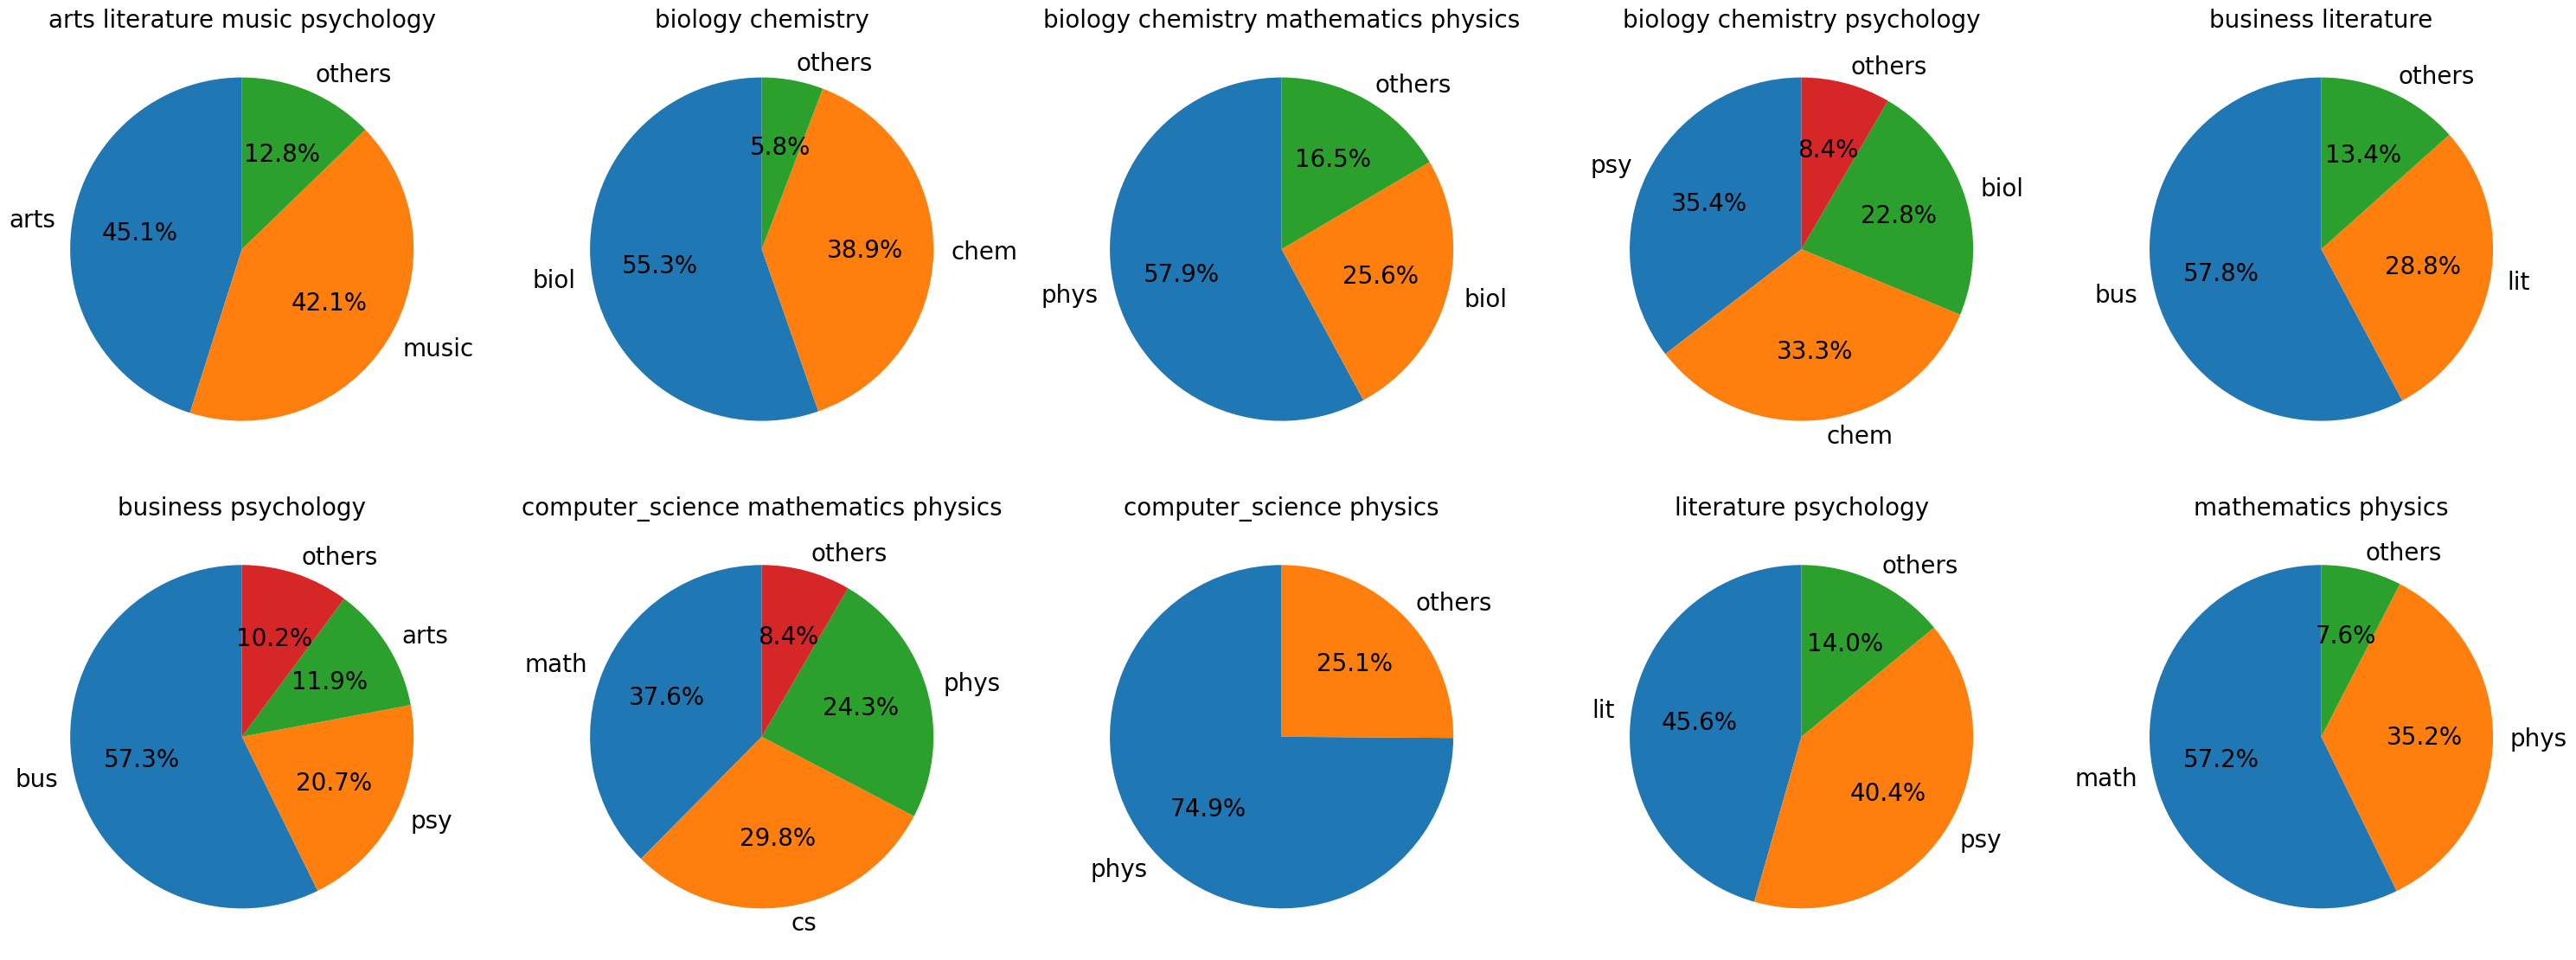

In [167]:
def format_duration(milliseconds):
    seconds, ms = divmod(milliseconds, 1000)
    minutes, seconds = divmod(seconds, 60)
    hours, minutes = divmod(minutes, 60)
    
    formatted_duration = f"{hours:02}:{minutes:02}:{seconds:02}.{ms:03}"
    return formatted_duration

watch_times = recommending_3_df.groupby(['profile', 'categories'])['action_duration'].sum().reset_index(name='total_watch_time')
total_watch_time_df = watch_times.groupby('profile')['total_watch_time'].sum().reset_index(name='total_watch_time')

# print(watch_times.head(10))
# print(total_watch_time_df.head(10))

profiles = total_watch_time_df['profile'].unique()
totals = total_watch_time_df['total_watch_time'].to_list()

disciplines = ['arts', 'biol', 'bus', 'chem', 'cs', 'lit', 'math', 'music', 'phys', 'psy']

data = {p: [] for p in profiles}
for p, t in zip(profiles, totals):
    watch_percentages = []
    times = watch_times[watch_times['profile'] == p]
    for time in times['total_watch_time'].to_list():
        percentage = time * 100 / t
        # percentage = round(percentage, 2)
        watch_percentages.append(percentage)
    data[p] = watch_percentages

# for key, value in data.items():
#     print(key)
#     print(value)
#     print('---')

# Number of profiles and disciplines
n_profiles = len(profiles)
n_disciplines = len(disciplines)

# Set up the figure with a grid of subplots
cols = 5
rows = (n_profiles + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(30, 12))

# Ensure axes is always iterable
axes = axes.flatten()

# Plot data for each profile
for i, profile in enumerate(profiles):
    values = data[profile].copy()
    labels = disciplines.copy()

    # print(profile)
    # print('before sorting')
    # print(labels)
    # print(values)

    # Sorting list
    for index in range(len(values) - 1):
        for jndex in range(index + 1, len(values)):
            if values[jndex] > values[index]:
                # Swapping values
                copy = values[index]
                values[index] = values[jndex]
                values[jndex] = copy

                # Swapping disciplines
                copy = labels[index]
                labels[index] = labels[jndex]
                labels[jndex] = copy

    # print('after sorting')
    # print(labels)
    # print(values)

    # print()


    total = 0
    data_points = []
    display = []
    for v, l in zip(values, labels):
        if v >= 10:
            data_points.append(v)
            display.append(l)
        else:
            total += v
    
    data_points.append(total)
    display.append('others')

    # explode = [0.1] * len(data_points)
    wedges, texts, autotexts = axes[i].pie(data_points, labels=display, autopct='%1.1f%%', startangle=90, textprops={'fontsize': 20})
    axes[i].set_title(profile, fontsize=20)

    # # Create legend with labels and percentages
    # legend_labels = [f'{label} ({value:.1f}%)' for label, value in zip(display, data_points)]
    # axes[i].legend(wedges, legend_labels, loc="right", bbox_to_anchor=(1.5, 0.5), fontsize=18)

# Remove empty subplots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

# Add a big title to the whole plot
# fig.suptitle('Experiment 3: watch percentage by category per profile', fontsize=22)

# Display plot
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

---
## Experiment 4
---

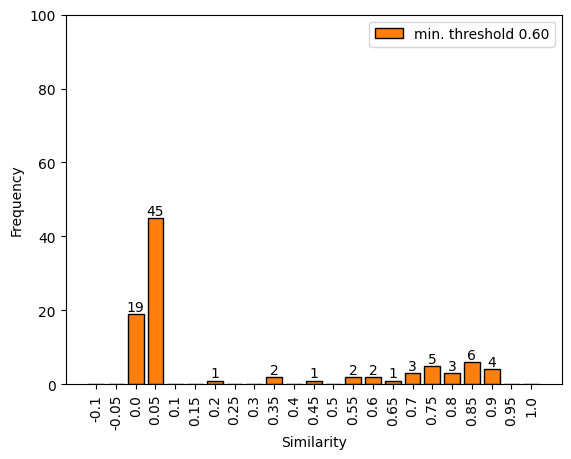

In [168]:
classes = []
index = -0.1
while index <= 1:
    classes.append(index)
    index += 0.05
    index = round(index, 2)
display_classes = [str(c) for c in classes]

values = [0 for _ in range(len(classes))]
for s in profiling_4_df['similarity'].to_list():
    flag = False
    for i in range(0, len(classes) - 1):
        if flag:
            continue
        lower_bound = classes[i]
        upper_bound = classes[i+1]
        if s >= lower_bound and s < upper_bound:
            flag = True
            values[i]+=1
    if not flag:
        values[len(classes) - 1]+=1

plt.bar(display_classes, values, edgecolor='black', color='tab:orange', label='min. threshold 0.60')

# plt.title('Experiment 4: bot and user vector similarities distribution')
plt.legend()
plt.xlabel('Similarity')
plt.ylabel('Frequency')
plt.ylim(0,100)
plt.xticks(display_classes, rotation=90)

# Display the number of elements on top of each bar
for i, value in enumerate(values):
    if value != 0:
        plt.text(i, value, str(value), ha='center', va='bottom')

plt.show()

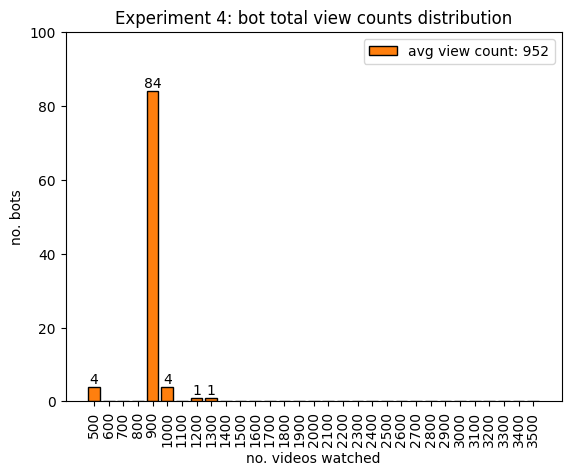

In [169]:
total_view_counts = recommending_4_df.groupby('user').size().reset_index(name='view_count')

avg_total_views = sum(total_view_counts['view_count'].to_list()) // len(total_view_counts['view_count'].to_list())

classes = []
index = 500
while index <= 3500:
    classes.append(index)
    index += 100
display_classes = [str(c) for c in classes]

values = [0 for _ in range(len(classes))]
for v in total_view_counts['view_count'].to_list():
    flag = False
    for i in range(0, len(classes) - 1):
        if flag:
            continue
        lower_bound = classes[i]
        upper_bound = classes[i+1]
        if v >= lower_bound and v < upper_bound:
            flag = True
            values[i]+=1
    if not flag:
        values[len(classes) - 1]+=1

plt.bar(display_classes, values, edgecolor='black', color='tab:orange', label=f'avg view count: {avg_total_views}')

plt.title('Experiment 4: bot total view counts distribution')
plt.legend()
plt.xlabel('no. videos watched')
plt.ylabel('no. bots')
plt.ylim(0,100)
plt.xticks(display_classes, rotation=90)

# Display the number of elements on top of each bar
for i, value in enumerate(values):
    if value != 0:
        plt.text(i, value, str(value), ha='center', va='bottom')

plt.show()

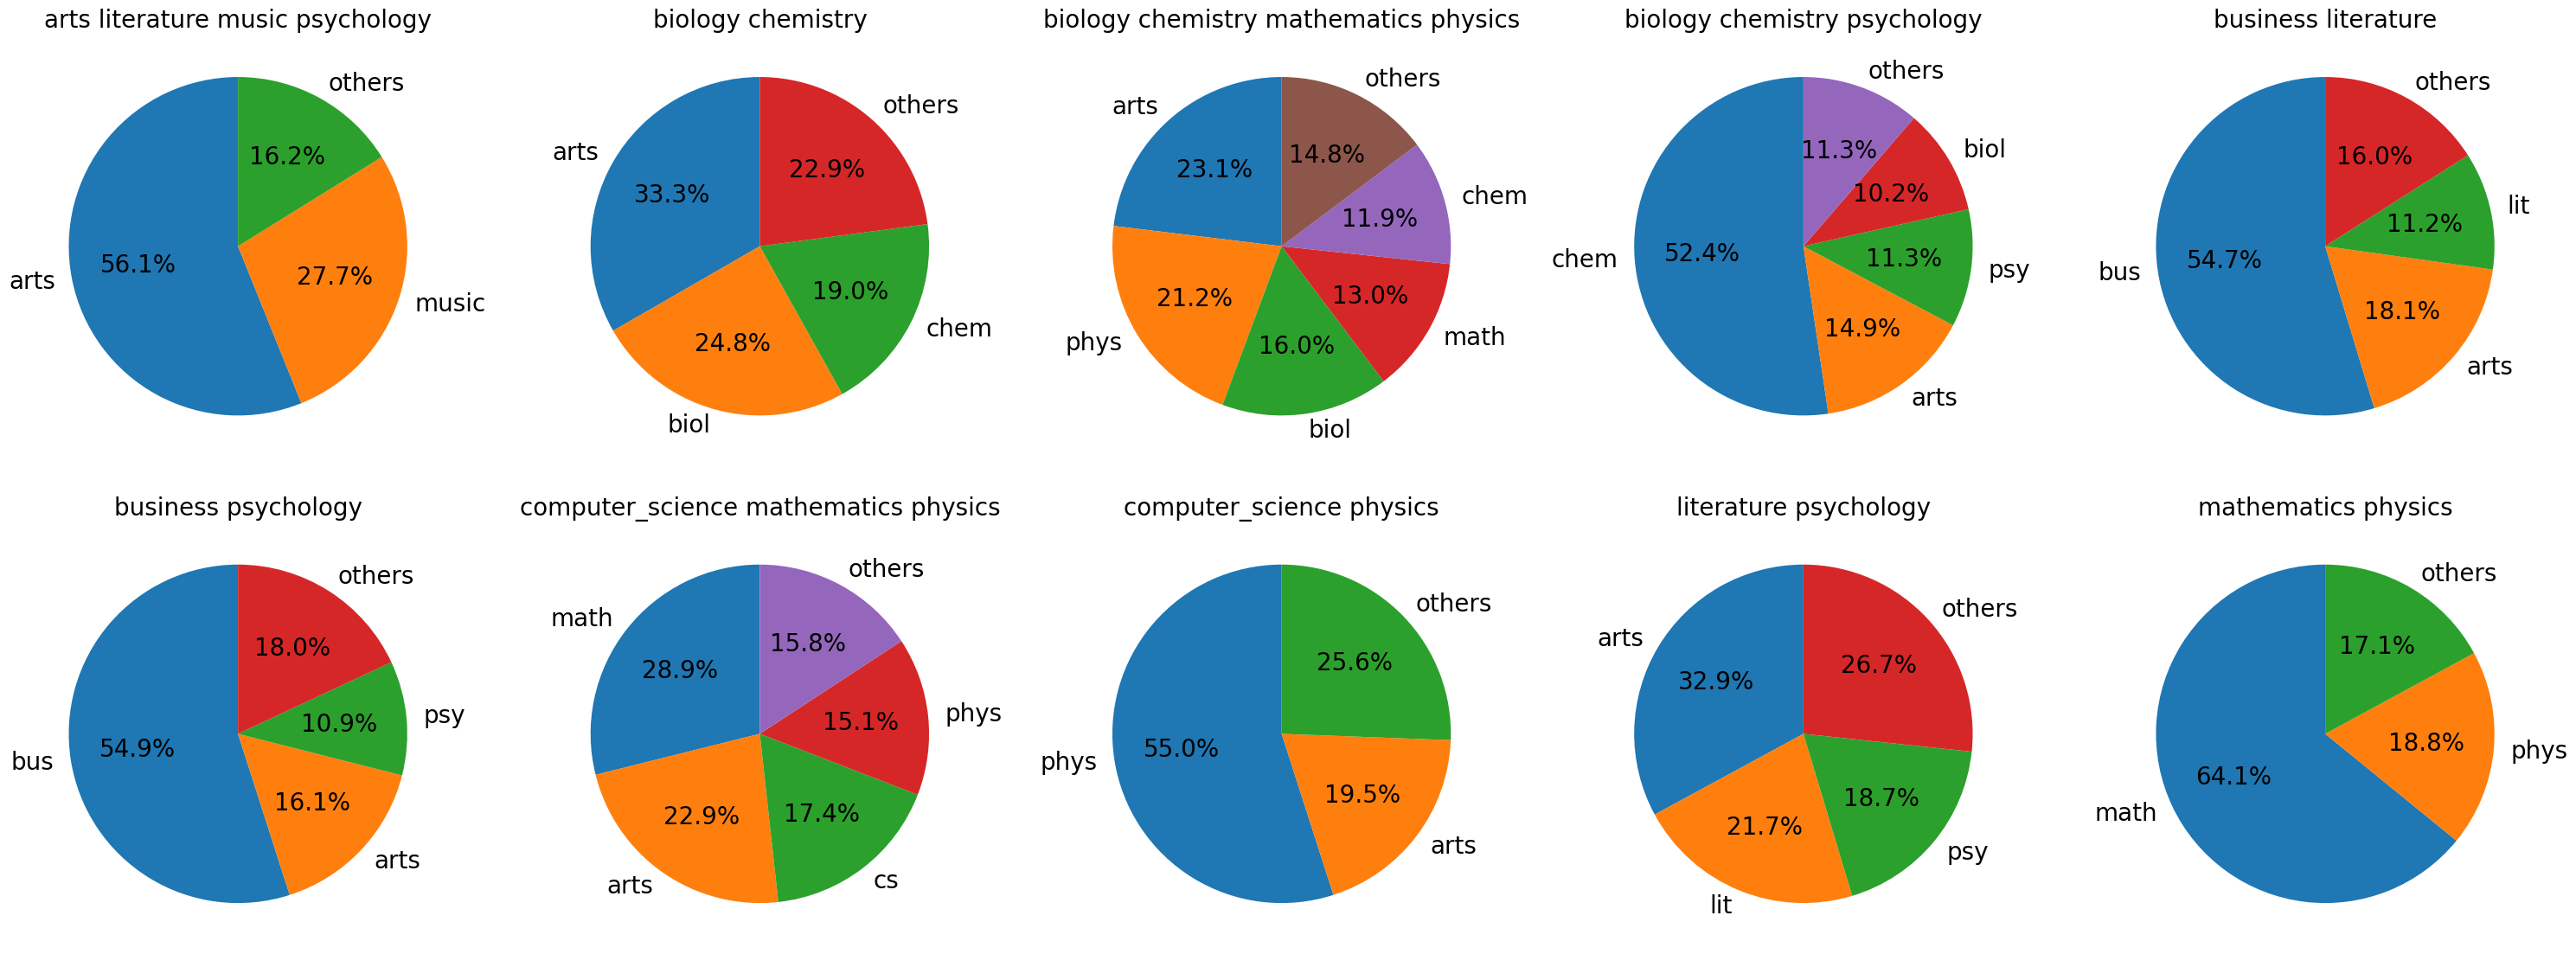

In [170]:
def format_duration(milliseconds):
    seconds, ms = divmod(milliseconds, 1000)
    minutes, seconds = divmod(seconds, 60)
    hours, minutes = divmod(minutes, 60)
    
    formatted_duration = f"{hours:02}:{minutes:02}:{seconds:02}.{ms:03}"
    return formatted_duration

watch_times = recommending_4_df.groupby(['profile', 'categories'])['action_duration'].sum().reset_index(name='total_watch_time')
total_watch_time_df = watch_times.groupby('profile')['total_watch_time'].sum().reset_index(name='total_watch_time')

# print(watch_times.head(10))
# print(total_watch_time_df.head(10))

profiles = total_watch_time_df['profile'].unique()
totals = total_watch_time_df['total_watch_time'].to_list()

disciplines = ['arts', 'biol', 'bus', 'chem', 'cs', 'lit', 'math', 'music', 'phys', 'psy']

data = {p: [] for p in profiles}
for p, t in zip(profiles, totals):
    watch_percentages = []
    times = watch_times[watch_times['profile'] == p]
    for time in times['total_watch_time'].to_list():
        percentage = time * 100 / t
        # percentage = round(percentage, 2)
        watch_percentages.append(percentage)
    data[p] = watch_percentages

# for key, value in data.items():
#     print(key)
#     print(value)
#     print('---')

# Number of profiles and disciplines
n_profiles = len(profiles)
n_disciplines = len(disciplines)

# Set up the figure with a grid of subplots
cols = 5
rows = (n_profiles + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(30, 12))

# Ensure axes is always iterable
axes = axes.flatten()

# Plot data for each profile
for i, profile in enumerate(profiles):
    values = data[profile].copy()
    labels = disciplines.copy()

    # print(profile)
    # print('before sorting')
    # print(labels)
    # print(values)

    # Sorting list
    for index in range(len(values) - 1):
        for jndex in range(index + 1, len(values)):
            if values[jndex] > values[index]:
                # Swapping values
                copy = values[index]
                values[index] = values[jndex]
                values[jndex] = copy

                # Swapping disciplines
                copy = labels[index]
                labels[index] = labels[jndex]
                labels[jndex] = copy

    # print('after sorting')
    # print(labels)
    # print(values)

    # print()


    total = 0
    data_points = []
    display = []
    for v, l in zip(values, labels):
        if v >= 10:
            data_points.append(v)
            display.append(l)
        else:
            total += v
    
    data_points.append(total)
    display.append('others')

    # explode = [0.1] * len(data_points)
    wedges, texts, autotexts = axes[i].pie(data_points, labels=display, autopct='%1.1f%%', startangle=90, textprops={'fontsize': 20})
    axes[i].set_title(profile, fontsize=20)

    # # Create legend with labels and percentages
    # legend_labels = [f'{label} ({value:.1f}%)' for label, value in zip(display, data_points)]
    # axes[i].legend(wedges, legend_labels, loc="right", bbox_to_anchor=(1.5, 0.5), fontsize=18)

# Remove empty subplots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

# Add a big title to the whole plot
# fig.suptitle('Experiment 4: watch percentage by category per profile', fontsize=22)

# Display plot
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

---
## Experiment 5
---


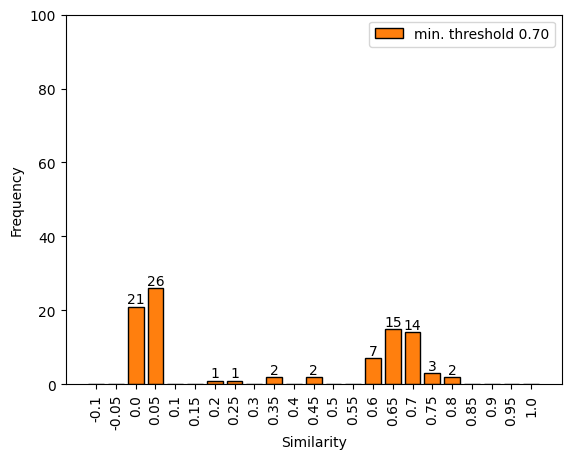

In [171]:
classes = []
index = -0.1
while index <= 1:
    classes.append(index)
    index += 0.05
    index = round(index, 2)
display_classes = [str(c) for c in classes]

values = [0 for _ in range(len(classes))]
for s in profiling_5_df['similarity'].to_list():
    flag = False
    for i in range(0, len(classes) - 1):
        if flag:
            continue
        lower_bound = classes[i]
        upper_bound = classes[i+1]
        if s >= lower_bound and s < upper_bound:
            flag = True
            values[i]+=1
    if not flag:
        values[len(classes) - 1]+=1

plt.bar(display_classes, values, edgecolor='black', color='tab:orange', label='min. threshold 0.70')

# plt.title('Experiment 5: bot and user vector similarities distribution')
plt.legend()
plt.xlabel('Similarity')
plt.ylabel('Frequency')
plt.ylim(0,100)
plt.xticks(display_classes, rotation=90)

# Display the number of elements on top of each bar
for i, value in enumerate(values):
    if value != 0:
        plt.text(i, value, str(value), ha='center', va='bottom')

plt.show()

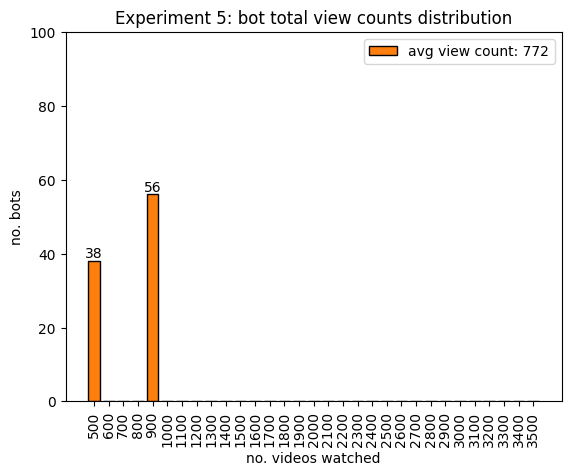

In [172]:
total_view_counts = recommending_5_df.groupby('user').size().reset_index(name='view_count')

avg_total_views = sum(total_view_counts['view_count'].to_list()) // len(total_view_counts['view_count'].to_list())

classes = []
index = 500
while index <= 3500:
    classes.append(index)
    index += 100
display_classes = [str(c) for c in classes]

values = [0 for _ in range(len(classes))]
for v in total_view_counts['view_count'].to_list():
    flag = False
    for i in range(0, len(classes) - 1):
        if flag:
            continue
        lower_bound = classes[i]
        upper_bound = classes[i+1]
        if v >= lower_bound and v < upper_bound:
            flag = True
            values[i]+=1
    if not flag:
        values[len(classes) - 1]+=1

plt.bar(display_classes, values, edgecolor='black', color='tab:orange', label=f'avg view count: {avg_total_views}')

plt.title('Experiment 5: bot total view counts distribution')
plt.legend()
plt.xlabel('no. videos watched')
plt.ylabel('no. bots')
plt.ylim(0,100)
plt.xticks(display_classes, rotation=90)

# Display the number of elements on top of each bar
for i, value in enumerate(values):
    if value != 0:
        plt.text(i, value, str(value), ha='center', va='bottom')

plt.show()

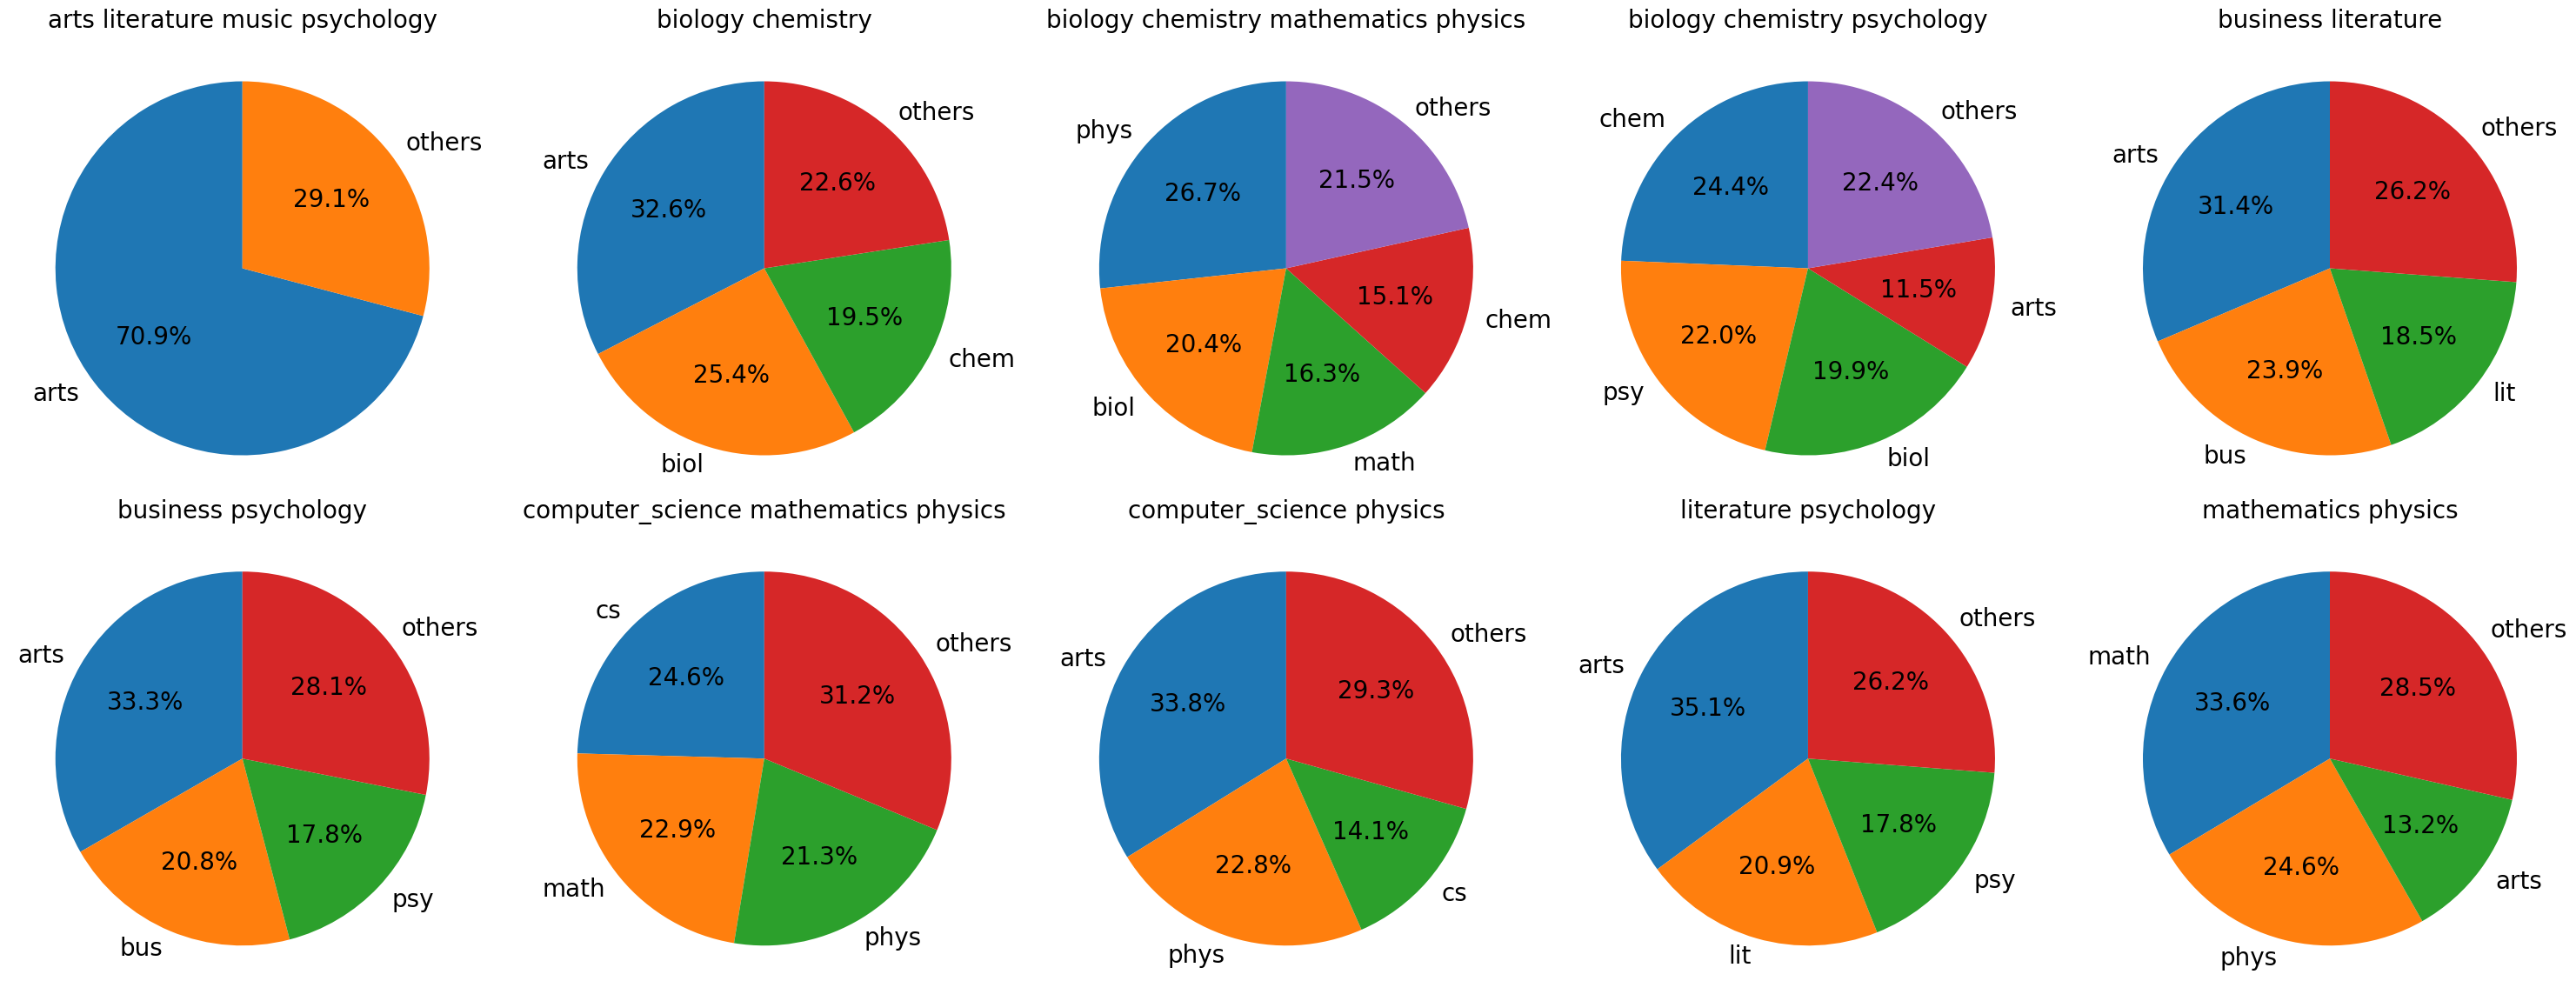

In [173]:
def format_duration(milliseconds):
    seconds, ms = divmod(milliseconds, 1000)
    minutes, seconds = divmod(seconds, 60)
    hours, minutes = divmod(minutes, 60)
    
    formatted_duration = f"{hours:02}:{minutes:02}:{seconds:02}.{ms:03}"
    return formatted_duration

watch_times = recommending_5_df.groupby(['profile', 'categories'])['action_duration'].sum().reset_index(name='total_watch_time')
total_watch_time_df = watch_times.groupby('profile')['total_watch_time'].sum().reset_index(name='total_watch_time')

# print(watch_times.head(10))
# print(total_watch_time_df.head(10))

profiles = total_watch_time_df['profile'].unique()
totals = total_watch_time_df['total_watch_time'].to_list()

disciplines = ['arts', 'biol', 'bus', 'chem', 'cs', 'lit', 'math', 'music', 'phys', 'psy']

data = {p: [] for p in profiles}
for p, t in zip(profiles, totals):
    watch_percentages = []
    times = watch_times[watch_times['profile'] == p]
    for time in times['total_watch_time'].to_list():
        percentage = time * 100 / t
        # percentage = round(percentage, 2)
        watch_percentages.append(percentage)
    data[p] = watch_percentages

# for key, value in data.items():
#     print(key)
#     print(value)
#     print('---')

# Number of profiles and disciplines
n_profiles = len(profiles)
n_disciplines = len(disciplines)

# Set up the figure with a grid of subplots
cols = 5
rows = (n_profiles + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(30, 12))

# Ensure axes is always iterable
axes = axes.flatten()

# Plot data for each profile
for i, profile in enumerate(profiles):
    values = data[profile].copy()
    labels = disciplines.copy()

    # print(profile)
    # print('before sorting')
    # print(labels)
    # print(values)

    # Sorting list
    for index in range(len(values) - 1):
        for jndex in range(index + 1, len(values)):
            if values[jndex] > values[index]:
                # Swapping values
                copy = values[index]
                values[index] = values[jndex]
                values[jndex] = copy

                # Swapping disciplines
                copy = labels[index]
                labels[index] = labels[jndex]
                labels[jndex] = copy

    # print('after sorting')
    # print(labels)
    # print(values)

    # print()


    total = 0
    data_points = []
    display = []
    for v, l in zip(values, labels):
        if v >= 10:
            data_points.append(v)
            display.append(l)
        else:
            total += v
    
    data_points.append(total)
    display.append('others')

    # explode = [0.1] * len(data_points)
    wedges, texts, autotexts = axes[i].pie(data_points, labels=display, autopct='%1.1f%%', startangle=90, textprops={'fontsize': 20})
    axes[i].set_title(profile, fontsize=20)

    # # Create legend with labels and percentages
    # legend_labels = [f'{label} ({value:.1f}%)' for label, value in zip(display, data_points)]
    # axes[i].legend(wedges, legend_labels, loc="right", bbox_to_anchor=(1.5, 0.5), fontsize=18)

# Remove empty subplots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

# Add a big title to the whole plot
# fig.suptitle('Experiment 5: watch percentage by category per profile', fontsize=22)

# Display plot
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

---
## Experiment Multiple
---

In [174]:
profiling_multiple_df.head(10)
user_vector = profiling_multiple_df['user_vector'].to_list()[0]
print(user_vector)
user_vector = [str(round(float(e), 2)) for e in user_vector.split(' ')]
print(user_vector)
user_vector = ' '.join(user_vector)
print(user_vector)

data = {
    '': 'bot1',
    'bot vector': profiling_multiple_df['bot_vector'].to_list(),
    'user vector': [user_vector],
    'similarity': profiling_multiple_df['similarity'].to_list(),
    'view count': [len(recommending_multiple_df)]
}

df = pd.DataFrame(data)
df.head(10)

0.2953946 0.2842729 0.2743393 0.2455520 0.3664799 0.2814868 0.3338687 0.3646715 0.4052906 0.2722438
['0.3', '0.28', '0.27', '0.25', '0.37', '0.28', '0.33', '0.36', '0.41', '0.27']
0.3 0.28 0.27 0.25 0.37 0.28 0.33 0.36 0.41 0.27


,,bot vector,user vector,similarity,view count
0,bot1,0.0 0.0 0.0 0.0 0.3 0.0 0.7 0.0 0.5 0.0,0.3 0.28 0.27 0.25 0.37 0.28 0.33 0.36 0.41 0.27,0.677526,4872


In [175]:
recommending_multiple_df.head(10)
print(len(recommending_multiple_df))

4872


---
# Other
---

In [176]:
# videos_df.head(10)
category_counts = videos_df['category'].value_counts()
print(category_counts)

category
music               59
business            58
chemistry           54
mathematics         52
biology             50
physics             50
computer_science    48
psychology          46
arts                42
literature          41
Name: count, dtype: int64


In [177]:
# view_counts = recommending_df.groupby(['profile', 'categories']).size().reset_index(name='view_count')

# disciplines = ['arts', 'biol', 'bus', 'chem', 'cs', 'lit', 'math', 'music', 'phys', 'psy']
# profiles = [profile for profile in view_counts['profile'].unique()]
# # for i in range(len(view_counts['profile'].unique())):
# #     profiles.append('Profile ' + str(i + 1))

# data = {p: [] for p in profiles}

# for key, profile in zip(data.keys(), view_counts['profile'].unique()):
#     filtered_df = view_counts[view_counts['profile'] == profile]
#     data[key] = filtered_df['view_count'].to_list()

# # Number of profiles and disciplines
# n_profiles = len(profiles)
# n_disciplines = len(disciplines)

# # Set up the figure with a grid of subplots
# cols = 5
# rows = (n_profiles + cols - 1) // cols
# fig, axes = plt.subplots(rows, cols, figsize=(20, 10))

# # Ensure axes is always iterable
# axes = axes.flatten()

# # Color for all bars
# bar_color = 'tab:orange'

# # Plot data for each profile
# for i, profile in enumerate(profiles):
#     axes[i].bar(disciplines, data[profile], color=bar_color, edgecolor='black')
#     axes[i].set_title(profile)
#     axes[i].set_ylabel('View Count')
#     axes[i].set_xticks(np.arange(n_disciplines))
#     axes[i].set_xticklabels(disciplines, rotation=45, fontsize=8)

# # Remove empty subplots
# for j in range(i+1, len(axes)):
#     fig.delaxes(axes[j])

# # Add a big title to the whole plot
# fig.suptitle('Experiment 1', fontsize=16)

# # Display plot
# plt.tight_layout(rect=[0, 0.04, 1, 0.96])
# plt.show()
